# 数据处理

In [7]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.integrate import solve_ivp
from scipy.optimize import least_squares

# 统一从 configs.json 读取参数
_cfg_candidates = [
    Path.cwd() / "parameters" / "configs.json",
    Path.cwd() / "SEIR" / "parameters" / "configs.json",
]
cfg_path = next((p for p in _cfg_candidates if p.exists()), None)
if cfg_path is None:
    raise FileNotFoundError("未找到 configs.json，请确认位于 SEIR/parameters/ 目录")

with open(cfg_path, "r", encoding="utf-8") as f:
    CFG = json.load(f)

MODEL = CFG["model_parameters"]
POP = CFG["population"]
OPT = CFG["optimization"]
DP = CFG["data_processing"]
FP = CFG["file_paths"]
CV = CFG["cross_validation"]
RT = CFG["runtime"]

N = float(POP["N"]["value"])
sigma = float(MODEL["sigma"]["value"])
gamma = float(MODEL["gamma"]["value"])
omega_init = float(MODEL["omega"]["value"])
E0_mult = float(POP["initial_conditions"]["E0_multiplier"])
ili_scale = float(DP["ili_pct_scale"])


In [8]:
# 1) 读取数据并构造“扩窗滚动交叉验证”折
seir_dir = cfg_path.parent.parent
data_path = (seir_dir / FP["realistic_data"]).resolve()
if not data_path.exists():
    data_path = (Path.cwd() / "data" / Path(FP["realistic_data"]).name).resolve()

df = pd.read_csv(data_path)
df["week_start"] = pd.to_datetime(df["week_start"], errors="coerce")
df[DP["target_col"]] = pd.to_numeric(df[DP["target_col"]], errors="coerce")
df["h3n2_pct"] = pd.to_numeric(df.get("h3n2_pct", DP["h3n2_missing_value"]), errors="coerce").fillna(DP["h3n2_missing_value"])
df = df.dropna(subset=["week_start", DP["target_col"]]).sort_values("week_start").copy()

df["year"] = (
    pd.to_numeric(df["iso_year"], errors="coerce")
    if "iso_year" in df.columns
    else df["week_start"].dt.year
).astype(int)

years = sorted(df["year"].unique())

# 扩窗: [start_year, ..., valid_year-1] 训练, valid_year 验证
expanding_folds = []
for i in range(1, len(years)):
    train_years = years[:i]
    valid_year = years[i]
    expanding_folds.append((train_years, valid_year))

print("数据文件:", data_path)
print(f"年份范围: {years[0]} - {years[-1]}")
print(f"扩窗滚动折数: {len(expanding_folds)}")

数据文件: D:\HP\OneDrive\Desktop\学校\课程\专业课\数学建模\课程项目\Mathematical-Modeling-Course-Project\data\china_flu_realistic_final.csv
年份范围: 2005 - 2026
扩窗滚动折数: 21


In [9]:
# 2) 每个折：扩窗训练 + 下一年验证，拟合 SEIR+seasonal+exogenous

def fit_one_fold(train_df, valid_df, omega_start):
    fold_df = pd.concat([train_df, valid_df], axis=0).sort_values("week_start").copy()
    start_date = fold_df["week_start"].min()

    # 统一绝对时间轴（以折起点为0天）
    t_all = (fold_df["week_start"] - start_date).dt.days.to_numpy(dtype=float)
    h3_all = fold_df["h3n2_pct"].to_numpy(dtype=float)

    t_train = (train_df["week_start"] - start_date).dt.days.to_numpy(dtype=float)
    t_valid = (valid_df["week_start"] - start_date).dt.days.to_numpy(dtype=float)

    y_train = train_df[DP["target_col"]].to_numpy(dtype=float) / ili_scale
    y_valid = valid_df[DP["target_col"]].to_numpy(dtype=float) / ili_scale

    # c 固定：用训练集低分位数表征背景基线
    c_fixed = float(np.percentile(y_train, DP["percentile_baseline"]))

    # 用训练集构建周季节因子
    tmp = train_df.copy()
    tmp["week_of_year"] = tmp["week_start"].dt.isocalendar().week.astype(int)

    week_mean = tmp.groupby("week_of_year")[DP["target_col"]].mean()
    week_count = int(RT["seasonal_weeks"])
    week_mean = week_mean.reindex(np.arange(1, week_count + 1), method="nearest")
    season_week = (week_mean / week_mean.mean()).to_numpy(dtype=float)
    season_week = np.clip(season_week, RT["season_week_clip"][0], RT["season_week_clip"][1])

    season_week_x = (np.arange(1, week_count + 1) - 1) * RT["days_per_week"]
    season_week_ext = np.r_[season_week, season_week[0]]
    season_week_x_ext = np.r_[season_week_x, week_count * RT["days_per_week"]]

    def h3_interp(t):
        return np.interp(t, t_all, h3_all)

    def season_interp(t):
        t_mod = np.mod(t, week_count * RT["days_per_week"])
        return np.interp(t_mod, season_week_x_ext, season_week_ext)

    def seir_rhs(t, y, beta0, a, phi, w_h3, w_season, omega):
        s, e, i, r = y
        season_cos = 1.0 + a * np.cos(2 * np.pi * (t / RT["days_per_year"]) - phi)
        season_data = season_interp(t)
        seasonal = season_cos * np.exp(w_season * (season_data - 1.0))
        h3_effect = np.exp(w_h3 * h3_interp(t))
        beta_t = beta0 * seasonal * h3_effect

        ds = -beta_t * s * i / N + omega * r
        de = beta_t * s * i / N - sigma * e
        di = sigma * e - gamma * i
        dr = gamma * i - omega * r
        return [ds, de, di, dr]

    def simulate(theta, t_eval, t_span, y0=None):
        beta0, a, phi, k, p, w_h3, w_season, omega = theta

        if y0 is None:
            i0 = max(N * max(y_train[0] - c_fixed, 1e-5) / max(k, 1e-6), 1.0)
            e0 = max(E0_mult * i0, 1.0)
            s0 = max(N - i0 - e0, 0.0)
            y0 = [s0, e0, i0, 0.0]

        sol = solve_ivp(
            seir_rhs,
            t_span=t_span,
            y0=y0,
            t_eval=t_eval,
            args=(beta0, a, phi, w_h3, w_season, omega),
            method=RT["ode_method"],
        )
        return sol

    def predict_series(theta, sol):
        _, _, _, k, p, _, _, _ = theta
        infection_ratio = np.clip(sol.y[2] / N, 0.0, 1.0)
        pred = c_fixed + k * (infection_ratio ** p)
        return np.clip(pred, 0.0, 1.0)

    def residual(theta):
        sol = simulate(theta, t_eval=t_train, t_span=(0.0, float(t_train.max())))
        if (not sol.success) or sol.y.shape[1] != len(t_train):
            return np.full_like(y_train, 1e6)
        pred = predict_series(theta, sol)
        if not np.isfinite(pred).all():
            return np.full_like(y_train, 1e6)
        return pred - y_train

    theta0 = np.array([
        OPT["beta0"]["initial"],
        OPT["a"]["initial"],
        OPT["phi"]["initial"],
        OPT["k"]["initial"],
        OPT["p"]["initial"],
        OPT["w_h3"]["initial"],
        OPT["w_season"]["initial"],
        omega_start,
    ], dtype=float)
    lb = np.array([
        OPT["beta0"]["bounds"][0],
        OPT["a"]["bounds"][0],
        OPT["phi"]["bounds"][0],
        OPT["k"]["bounds"][0],
        OPT["p"]["bounds"][0],
        OPT["w_h3"]["bounds"][0],
        OPT["w_season"]["bounds"][0],
        OPT["omega"]["bounds"][0],
    ], dtype=float)
    ub = np.array([
        OPT["beta0"]["bounds"][1],
        OPT["a"]["bounds"][1],
        OPT["phi"]["bounds"][1],
        OPT["k"]["bounds"][1],
        OPT["p"]["bounds"][1],
        OPT["w_h3"]["bounds"][1],
        OPT["w_season"]["bounds"][1],
        OPT["omega"]["bounds"][1],
    ], dtype=float)

    fit = least_squares(
        residual,
        x0=theta0,
        bounds=(lb, ub),
        loss=OPT["loss_function"],
        max_nfev=int(RT["optimizer_max_nfev"]),
    )

    # 验证段延续训练末状态
    sol_train = simulate(fit.x, t_eval=t_train, t_span=(0.0, float(t_train.max())))
    if (not sol_train.success) or sol_train.y.shape[1] == 0:
        raise ValueError("训练段积分失败，无法进行状态传递。")

    final_state = sol_train.y[:, -1]
    # t_valid 已经是相对折起点的绝对时间，无需再次平移
    t_start_valid = float(t_train.max())
    t_eval_valid = t_valid
    t_span_valid = (t_start_valid, float(t_valid.max()))

    sol_valid = simulate(fit.x, t_eval=t_eval_valid, t_span=t_span_valid, y0=final_state)
    if (not sol_valid.success) or sol_valid.y.shape[1] != len(t_valid):
        raise ValueError("验证段积分失败，请检查时间轴或参数范围。")

    pred_valid = predict_series(fit.x, sol_valid)

    mae = float(np.mean(np.abs(pred_valid - y_valid))) * ili_scale
    rmse = float(np.sqrt(np.mean((pred_valid - y_valid) ** 2))) * ili_scale

    pred_df = valid_df[["week_start", "year", DP["target_col"]]].copy()
    pred_df["pred_ili_pct"] = pred_valid * ili_scale

    return fit.x, mae, rmse, pred_df, c_fixed


metric_rows = []
pred_parts = []

for train_years, valid_year in expanding_folds:
    train_fold = df[df["year"].isin(train_years)].copy()
    valid_fold = df[df["year"] == valid_year].copy()

    if len(train_fold) < int(CV["min_train_samples"]) or len(valid_fold) < int(CV["min_valid_samples"]):
        continue

    theta, mae, rmse, fold_pred, c_fixed = fit_one_fold(train_fold, valid_fold, omega_init)
    metric_rows.append(
        {
            "train_year_start": min(train_years),
            "train_year_end": max(train_years),
            "valid_year": valid_year,
            "n_train": len(train_fold),
            "n_valid": len(valid_fold),
            "MAE_pct": mae,
            "RMSE_pct": rmse,
            "beta0": theta[0],
            "a": theta[1],
            "phi": theta[2],
            "k": theta[3],
            "p": theta[4],
            "omega": theta[7],
            "rho0": 0.0,
            "c_fixed_pct": c_fixed * ili_scale,
        }
    )
    pred_parts.append(fold_pred)

cv_metric_df = pd.DataFrame(metric_rows)
cv_pred_df = pd.concat(pred_parts, ignore_index=True) if pred_parts else pd.DataFrame()

print(f"完成折数: {len(cv_metric_df)}")

完成折数: 18


In [10]:
# 3) 输出滚动交叉验证指标
if cv_metric_df.empty:
    raise ValueError("没有可用折，请检查每年样本量。")

# 兼容扩窗列名与单年列名
if "train_year" in cv_metric_df.columns:
    show_cols = ["train_year", "valid_year", "n_train", "n_valid", "MAE_pct", "RMSE_pct", "omega"]
else:
    show_cols = ["train_year_start", "train_year_end", "valid_year", "n_train", "n_valid", "MAE_pct", "RMSE_pct", "omega"]

print(cv_metric_df[show_cols].to_string(index=False))
print("\n平均 MAE: {:.3f} pct".format(cv_metric_df["MAE_pct"].mean()))
print("平均 RMSE: {:.3f} pct".format(cv_metric_df["RMSE_pct"].mean()))
print("平均 omega: {:.5f} /day".format(cv_metric_df["omega"].mean()))

# 看一下最难拟合的3个验证年
print("\nRMSE最高的3个验证年:")
print(cv_metric_df.sort_values("RMSE_pct", ascending=False).head(3)[["valid_year", "RMSE_pct", "MAE_pct", "omega"]].to_string(index=False))

 train_year_start  train_year_end  valid_year  n_train  n_valid  MAE_pct  RMSE_pct    omega
             2005            2007        2008       67       27 0.884425  1.011335 0.009921
             2005            2008        2009       94       51 0.584192  0.758473 0.009925
             2005            2009        2010      145       52 0.720572  0.876553 0.009987
             2005            2010        2011      197       52 0.575985  0.677118 0.010020
             2005            2011        2012      249       52 1.068065  1.203635 0.009989
             2005            2012        2013      301       51 0.680639  0.864787 0.010009
             2005            2013        2014      352       52 0.919873  1.197193 0.009997
             2005            2014        2015      404       53 0.858946  1.143803 0.010001
             2005            2015        2016      457       52 0.831345  1.091917 0.010000
             2005            2016        2017      509       52 1.022574  1.3438

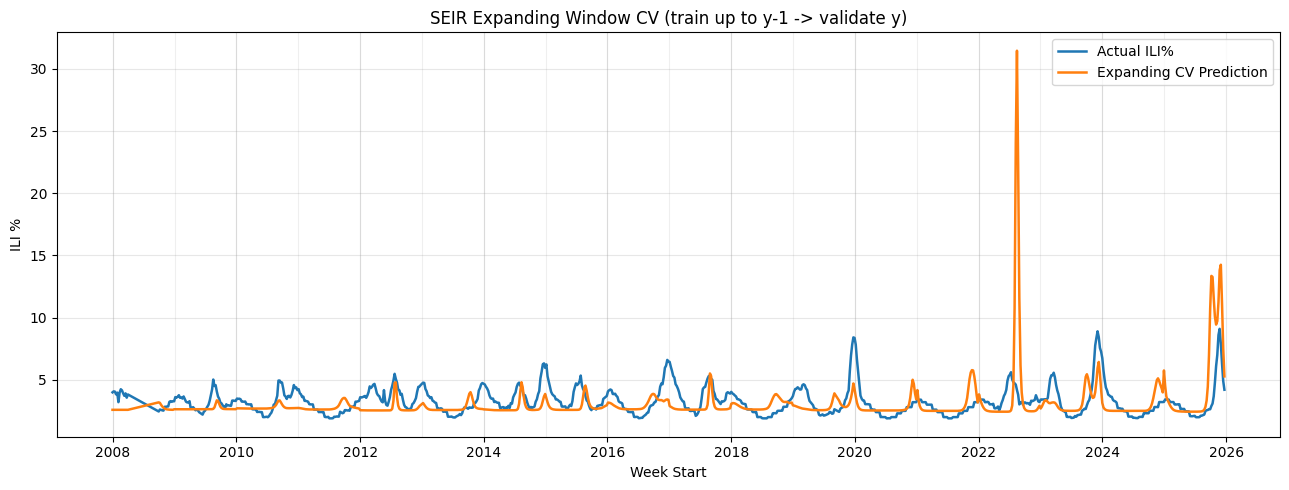

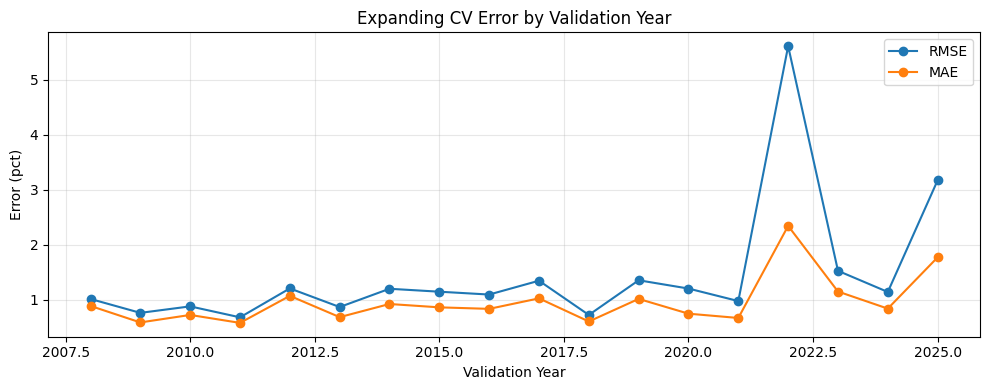

In [11]:
# 4) 绘图：逐年扩窗滚动验证预测 vs 真实
plot_df = cv_pred_df.sort_values("week_start").copy()

plt.figure(figsize=(13, 5))
plt.plot(plot_df["week_start"], plot_df["ili_pct"], label="Actual ILI%", linewidth=1.8)
plt.plot(plot_df["week_start"], plot_df["pred_ili_pct"], label="Expanding CV Prediction", linewidth=1.8)

for y in sorted(plot_df["year"].unique()):
    year_start = pd.Timestamp(f"{int(y)}-01-01")
    plt.axvline(year_start, color="gray", alpha=0.12, linewidth=0.8)

plt.title("SEIR Expanding Window CV (train up to y-1 -> validate y)")
plt.xlabel("Week Start")
plt.ylabel("ILI %")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(cv_metric_df["valid_year"], cv_metric_df["RMSE_pct"], marker="o", label="RMSE")
plt.plot(cv_metric_df["valid_year"], cv_metric_df["MAE_pct"], marker="o", label="MAE")
plt.title("Expanding CV Error by Validation Year")
plt.xlabel("Validation Year")
plt.ylabel("Error (pct)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

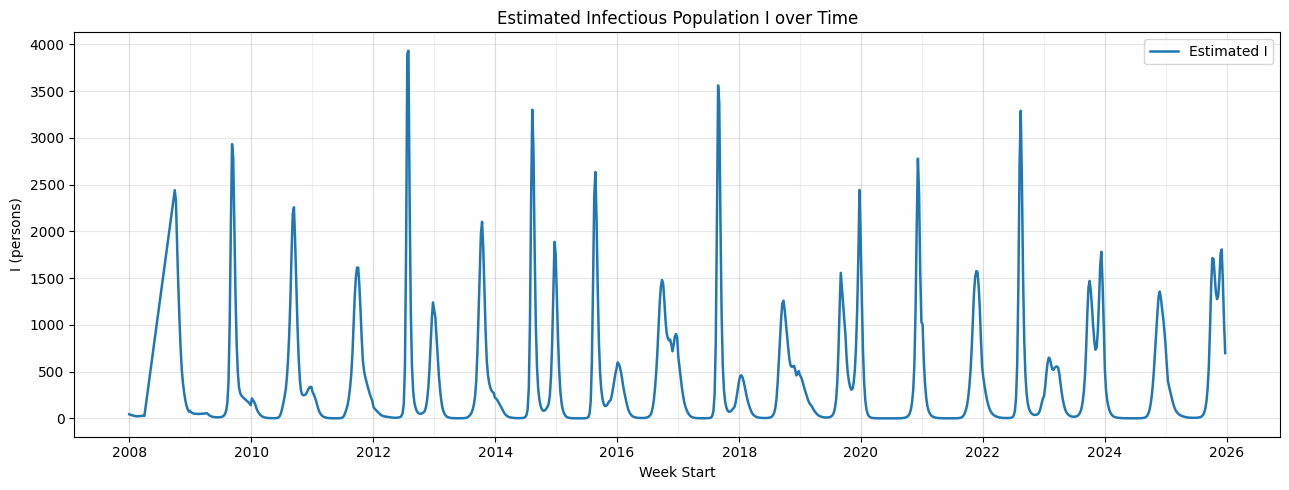

In [6]:
# 6) 对 SEIR 中的 I（感染者人数）作图
# 这里用已得到的预测值反推 I：
# pred = c + k * (I/N)^p  =>  I = N * ((pred - c)/k)^(1/p)

if cv_pred_df.empty or cv_metric_df.empty:
    raise ValueError("cv_pred_df 或 cv_metric_df 为空，无法绘制 I。")

# 将每个验证年的参数合并到逐周预测数据
param_cols = ["valid_year", "k", "p", "c_fixed_pct"]
i_plot_df = cv_pred_df.merge(
    cv_metric_df[param_cols],
    left_on="year",
    right_on="valid_year",
    how="left",
)

# 百分比转比例
pred_ratio = i_plot_df["pred_ili_pct"].to_numpy(dtype=float) / ili_scale
c_ratio = i_plot_df["c_fixed_pct"].to_numpy(dtype=float) / ili_scale
k = i_plot_df["k"].to_numpy(dtype=float)
p = i_plot_df["p"].to_numpy(dtype=float)

# 防止数值问题
base = np.clip((pred_ratio - c_ratio) / np.clip(k, 1e-8, None), 0.0, None)
i_est = N * np.power(base, 1.0 / np.clip(p, 1e-8, None))

i_plot_df["I_est"] = i_est

plt.figure(figsize=(13, 5))
plt.plot(i_plot_df["week_start"], i_plot_df["I_est"], linewidth=1.8, label="Estimated I")
for y in sorted(i_plot_df["year"].dropna().unique()):
    plt.axvline(pd.Timestamp(f"{int(y)}-01-01"), color="gray", alpha=0.12, linewidth=0.8)

plt.title("Estimated Infectious Population I over Time")
plt.xlabel("Week Start")
plt.ylabel("I (persons)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## 2) 剔除 2020–2022 后重跑并与原模型对比

本节在相同建模与优化设置下，去除 2020–2022 年数据后重新做扩窗滚动验证，并输出新误差图、新参数表和与原模型的对比。

=== 去除 2020-2022 后：新参数表（按验证年）===
 valid_year    beta0        a       phi    omega        k        p  MAE_pct  RMSE_pct
       2008 0.349892 0.200184 -0.000174 0.009921 0.252787 1.489578 0.884425  1.011335
       2009 0.350019 0.200072  0.000009 0.009925 0.231218 1.491497 0.584192  0.758473
       2010 0.350017 0.200004 -0.000014 0.009987 0.274861 1.442076 0.720572  0.876553
       2011 0.350039 0.200008 -0.000003 0.010020 0.260214 1.140020 0.575985  0.677118
       2012 0.350003 0.200015 -0.000015 0.009989 0.405531 1.422154 1.068065  1.203635
       2013 0.350000 0.200005 -0.000002 0.010009 0.608739 1.409530 0.680639  0.864787
       2014 0.349993 0.200024  0.000003 0.009997 0.367706 1.265106 0.919873  1.197193
       2015 0.350011 0.199997  0.000001 0.010001 0.242602 1.034536 0.858946  1.143803
       2016 0.349994 0.200004 -0.000002 0.010000 0.193099 0.909246 0.831345  1.091917
       2017 0.349997 0.200010  0.000012 0.009998 0.527226 1.359343 1.022574  1.343836
       2018 0.350004 

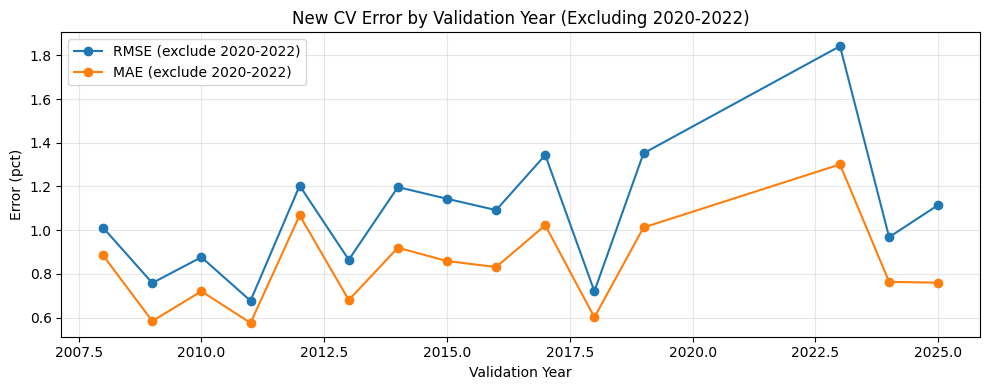

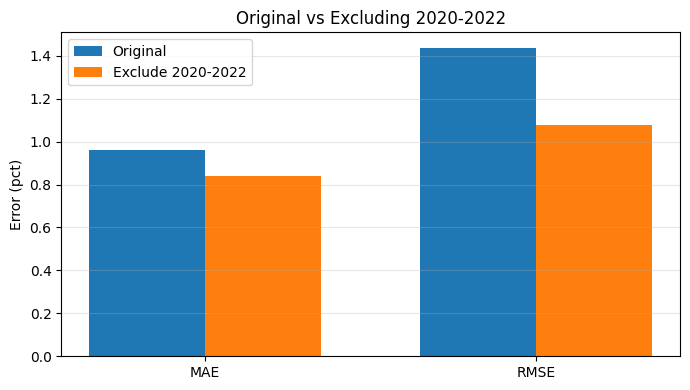

In [12]:
# 2.1 去除 2020-2022 后重跑扩窗CV + 新误差图 + 新参数表 + 与原模型对比

exclude_years = {2020, 2021, 2022}

# 备份原模型结果（如果当前会话已存在）
cv_metric_df_original = cv_metric_df.copy()
cv_pred_df_original = cv_pred_df.copy()

# 过滤数据并重建折
mask_keep = ~df["year"].isin(exclude_years)
df_no_covid = df[mask_keep].copy()
years_no_covid = sorted(df_no_covid["year"].unique())

expanding_folds_no_covid = []
for i in range(1, len(years_no_covid)):
    train_years = years_no_covid[:i]
    valid_year = years_no_covid[i]
    expanding_folds_no_covid.append((train_years, valid_year))

metric_rows_no_covid = []
pred_parts_no_covid = []

for train_years, valid_year in expanding_folds_no_covid:
    train_fold = df_no_covid[df_no_covid["year"].isin(train_years)].copy()
    valid_fold = df_no_covid[df_no_covid["year"] == valid_year].copy()

    if len(train_fold) < int(CV["min_train_samples"]) or len(valid_fold) < int(CV["min_valid_samples"]):
        continue

    theta, mae, rmse, fold_pred, c_fixed = fit_one_fold(train_fold, valid_fold, omega_init)
    metric_rows_no_covid.append(
        {
            "train_year_start": min(train_years),
            "train_year_end": max(train_years),
            "valid_year": int(valid_year),
            "n_train": len(train_fold),
            "n_valid": len(valid_fold),
            "MAE_pct": mae,
            "RMSE_pct": rmse,
            "beta0": theta[0],
            "a": theta[1],
            "phi": theta[2],
            "k": theta[3],
            "p": theta[4],
            "omega": theta[7],
            "rho0": 0.0,
            "c_fixed_pct": c_fixed * ili_scale,
        }
    )
    pred_parts_no_covid.append(fold_pred)

cv_metric_df_no_covid = pd.DataFrame(metric_rows_no_covid)
cv_pred_df_no_covid = pd.concat(pred_parts_no_covid, ignore_index=True) if pred_parts_no_covid else pd.DataFrame()

if cv_metric_df_no_covid.empty:
    raise ValueError("去除 2020-2022 后没有可用折，请检查样本量和最小样本阈值。")

print("=== 去除 2020-2022 后：新参数表（按验证年）===")
param_cols_show = ["valid_year", "beta0", "a", "phi", "omega", "k", "p", "MAE_pct", "RMSE_pct"]
print(cv_metric_df_no_covid[param_cols_show].to_string(index=False))

print("\n=== 汇总误差（新模型）===")
print("平均 MAE: {:.3f} pct".format(cv_metric_df_no_covid["MAE_pct"].mean()))
print("平均 RMSE: {:.3f} pct".format(cv_metric_df_no_covid["RMSE_pct"].mean()))

print("\n=== 与原模型对比（整体均值）===")
comp_df = pd.DataFrame(
    {
        "Model": ["Original (all years)", "Exclude 2020-2022"],
        "Mean_MAE_pct": [cv_metric_df_original["MAE_pct"].mean(), cv_metric_df_no_covid["MAE_pct"].mean()],
        "Mean_RMSE_pct": [cv_metric_df_original["RMSE_pct"].mean(), cv_metric_df_no_covid["RMSE_pct"].mean()],
        "Mean_beta0": [cv_metric_df_original["beta0"].mean(), cv_metric_df_no_covid["beta0"].mean()],
        "Mean_a": [cv_metric_df_original["a"].mean(), cv_metric_df_no_covid["a"].mean()],
        "Mean_phi": [cv_metric_df_original["phi"].mean(), cv_metric_df_no_covid["phi"].mean()],
        "Mean_omega": [cv_metric_df_original["omega"].mean(), cv_metric_df_no_covid["omega"].mean()],
    }
)
print(comp_df.to_string(index=False))

# 新误差图：按验证年展示去除后模型的 MAE/RMSE
plt.figure(figsize=(10, 4))
plt.plot(cv_metric_df_no_covid["valid_year"], cv_metric_df_no_covid["RMSE_pct"], marker="o", label="RMSE (exclude 2020-2022)")
plt.plot(cv_metric_df_no_covid["valid_year"], cv_metric_df_no_covid["MAE_pct"], marker="o", label="MAE (exclude 2020-2022)")
plt.title("New CV Error by Validation Year (Excluding 2020-2022)")
plt.xlabel("Validation Year")
plt.ylabel("Error (pct)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 原模型 vs 新模型 误差均值对比图
x = np.arange(2)
labels = ["MAE", "RMSE"]
orig_vals = [cv_metric_df_original["MAE_pct"].mean(), cv_metric_df_original["RMSE_pct"].mean()]
new_vals = [cv_metric_df_no_covid["MAE_pct"].mean(), cv_metric_df_no_covid["RMSE_pct"].mean()]

width = 0.35
plt.figure(figsize=(7, 4))
plt.bar(x - width/2, orig_vals, width=width, label="Original")
plt.bar(x + width/2, new_vals, width=width, label="Exclude 2020-2022")
plt.xticks(x, labels)
plt.ylabel("Error (pct)")
plt.title("Original vs Excluding 2020-2022")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

=== 参数跨年份稳定区间统计 ===
说明: ci95_* 为均值的95%置信区间；interval95_* 为参数经验95%区间(2.5%-97.5%)。
               model param  n_years      mean      std  ci95_low_mean  ci95_high_mean  interval95_low  interval95_high
Original (all years) beta0       18  0.349999 0.000029       0.349986        0.350013        0.349935         0.350030
Original (all years)     a       18  0.200018 0.000045       0.199997        0.200039        0.199990         0.200136
Original (all years)   phi       18 -0.000011 0.000042      -0.000030        0.000009       -0.000106         0.000011
Original (all years) omega       18  0.009991 0.000026       0.009979        0.010003        0.009923         0.010016
   Exclude 2020-2022 beta0       15  0.349998 0.000032       0.349982        0.350014        0.349927         0.350032
   Exclude 2020-2022     a       15  0.200022 0.000049       0.199997        0.200047        0.199991         0.200145
   Exclude 2020-2022   phi       15 -0.000012 0.000045      -0.000035        0.000011  

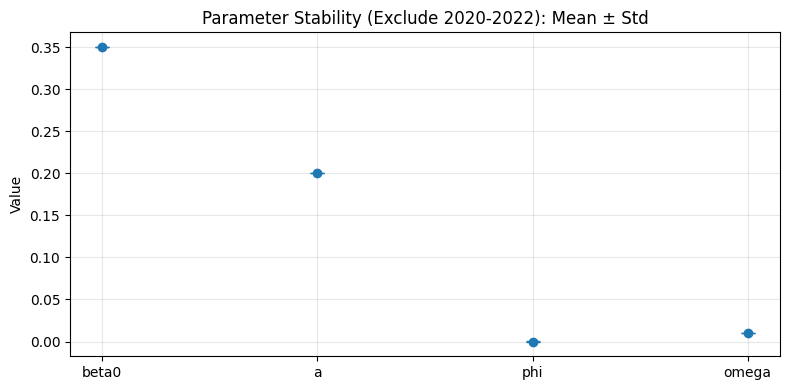

In [13]:
# 3) 参数跨年份稳定区间统计（beta0, a, phi, omega）

params_focus = ["beta0", "a", "phi", "omega"]


def summarize_param_stability(metric_df, model_name):
    rows = []
    for p_name in params_focus:
        vals = pd.to_numeric(metric_df[p_name], errors="coerce").dropna().to_numpy(dtype=float)
        n = len(vals)
        if n == 0:
            rows.append(
                {
                    "model": model_name,
                    "param": p_name,
                    "n_years": 0,
                    "mean": np.nan,
                    "std": np.nan,
                    "ci95_low_mean": np.nan,
                    "ci95_high_mean": np.nan,
                    "interval95_low": np.nan,
                    "interval95_high": np.nan,
                }
            )
            continue

        mean_v = float(np.mean(vals))
        std_v = float(np.std(vals, ddof=1)) if n > 1 else 0.0
        half_ci = 1.96 * std_v / np.sqrt(n) if n > 1 else 0.0
        q_low, q_high = np.quantile(vals, [0.025, 0.975])

        rows.append(
            {
                "model": model_name,
                "param": p_name,
                "n_years": n,
                "mean": mean_v,
                "std": std_v,
                "ci95_low_mean": mean_v - half_ci,
                "ci95_high_mean": mean_v + half_ci,
                "interval95_low": float(q_low),
                "interval95_high": float(q_high),
            }
        )

    return pd.DataFrame(rows)


stability_original = summarize_param_stability(cv_metric_df_original, "Original (all years)")
stability_no_covid = summarize_param_stability(cv_metric_df_no_covid, "Exclude 2020-2022")
stability_df = pd.concat([stability_original, stability_no_covid], ignore_index=True)

print("=== 参数跨年份稳定区间统计 ===")
print("说明: ci95_* 为均值的95%置信区间；interval95_* 为参数经验95%区间(2.5%-97.5%)。")
print(
    stability_df[
        [
            "model",
            "param",
            "n_years",
            "mean",
            "std",
            "ci95_low_mean",
            "ci95_high_mean",
            "interval95_low",
            "interval95_high",
        ]
    ].to_string(index=False)
)

# 可视化：新模型（剔除2020-2022）下四个参数的均值±标准差
plot_stats = stability_no_covid.set_index("param").loc[params_focus]
x = np.arange(len(params_focus))
means = plot_stats["mean"].to_numpy(dtype=float)
stds = plot_stats["std"].to_numpy(dtype=float)

plt.figure(figsize=(8, 4))
plt.errorbar(x, means, yerr=stds, fmt="o", capsize=5)
plt.xticks(x, params_focus)
plt.title("Parameter Stability (Exclude 2020-2022): Mean ± Std")
plt.ylabel("Value")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 4) 参数识别性检查：是否贴着初值不动

先把 beta0、a、phi、omega 和它们的初值逐年对比，再检查简化观测方程后参数是否仍然贴近初值。

=== 参数是否贴着初值不动 ===
说明: within_atol_ratio 表示与初值相差不超过 1e-3 的年份占比。
               model param  init      mean      std  mean_abs_dev  max_abs_dev  within_atol_ratio
Original (all years) beta0  0.35  0.349999 0.000029      0.000013     0.000108                1.0
Original (all years)     a  0.20  0.200018 0.000045      0.000021     0.000184                1.0
Original (all years)   phi  0.00 -0.000011 0.000042      0.000016     0.000174                1.0
Original (all years) omega  0.01  0.009991 0.000026      0.000014     0.000079                1.0
   Exclude 2020-2022 beta0  0.35  0.349998 0.000032      0.000016     0.000108                1.0
   Exclude 2020-2022     a  0.20  0.200022 0.000049      0.000025     0.000184                1.0
   Exclude 2020-2022   phi  0.00 -0.000012 0.000045      0.000018     0.000174                1.0
   Exclude 2020-2022 omega  0.01  0.009989 0.000028      0.000016     0.000079                1.0


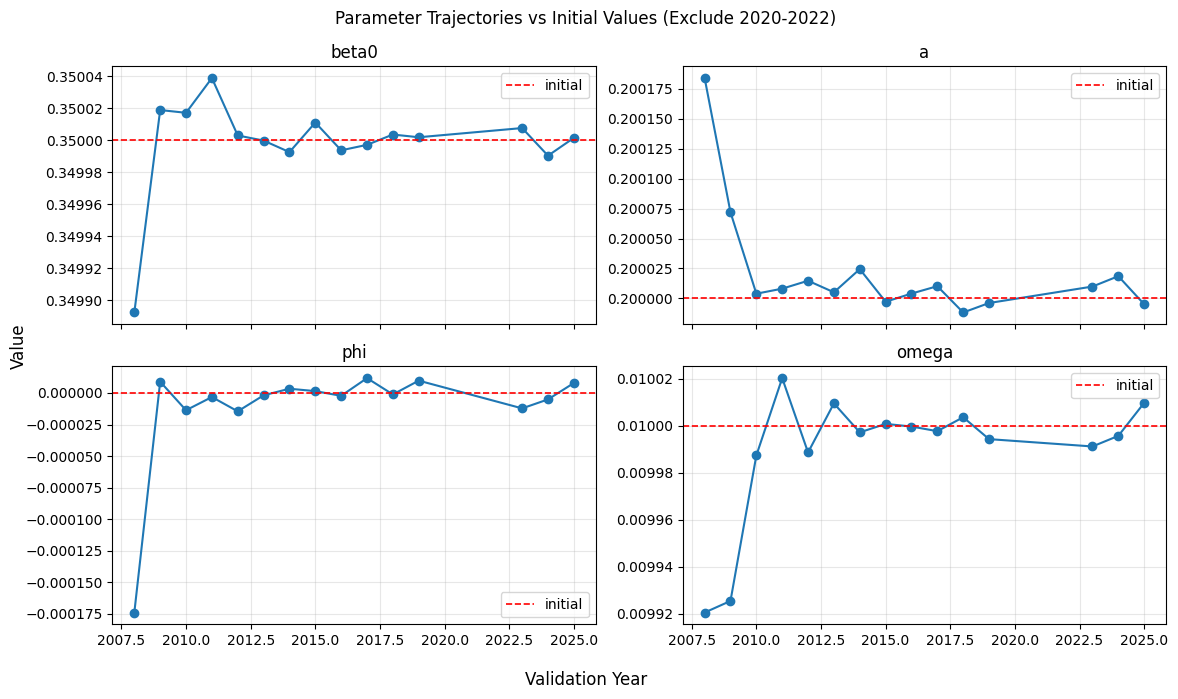

In [14]:
# 4.1 与初值偏移检查：原模型 vs 剔除 2020-2022

focus_params = ["beta0", "a", "phi", "omega"]
init_values = {name: float(OPT[name]["initial"]) for name in focus_params}

def build_drift_table(metric_df, model_name, atol=1e-3):
    rows = []
    for name in focus_params:
        vals = pd.to_numeric(metric_df[name], errors="coerce").dropna().to_numpy(dtype=float)
        init_v = init_values[name]
        abs_dev = np.abs(vals - init_v)
        rows.append(
            {
                "model": model_name,
                "param": name,
                "init": init_v,
                "mean": float(np.mean(vals)),
                "std": float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0,
                "mean_abs_dev": float(np.mean(abs_dev)) if len(abs_dev) else np.nan,
                "max_abs_dev": float(np.max(abs_dev)) if len(abs_dev) else np.nan,
                "within_atol_ratio": float(np.mean(abs_dev <= atol)) if len(abs_dev) else np.nan,
            }
        )
    return pd.DataFrame(rows)


drift_original = build_drift_table(cv_metric_df_original, "Original (all years)")
drift_no_covid = build_drift_table(cv_metric_df_no_covid, "Exclude 2020-2022")
drift_df = pd.concat([drift_original, drift_no_covid], ignore_index=True)

print("=== 参数是否贴着初值不动 ===")
print("说明: within_atol_ratio 表示与初值相差不超过 1e-3 的年份占比。")
print(
    drift_df[
        ["model", "param", "init", "mean", "std", "mean_abs_dev", "max_abs_dev", "within_atol_ratio"]
    ].to_string(index=False)
)

# 画出剔除 2020-2022 后的逐年参数值和初值线
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
axes = axes.ravel()
for ax, name in zip(axes, focus_params):
    ax.plot(cv_metric_df_no_covid["valid_year"], cv_metric_df_no_covid[name], marker="o", linewidth=1.5)
    ax.axhline(init_values[name], color="red", linestyle="--", linewidth=1.2, label="initial")
    ax.set_title(name)
    ax.grid(alpha=0.3)
    ax.legend()

fig.suptitle("Parameter Trajectories vs Initial Values (Exclude 2020-2022)")
fig.supxlabel("Validation Year")
fig.supylabel("Value")
plt.tight_layout()
plt.show()

=== 简化观测方程再拟合结果 ===
 valid_year    beta0        a           phi    omega        k  MAE_pct  RMSE_pct
       2008 0.349978 0.200051 -5.723507e-05 0.010042 0.245029 1.036847  1.164449
       2009 0.350022 0.199956  7.202491e-05 0.009980 0.244202 0.516810  0.678111
       2010 0.350003 0.199991 -6.355644e-06 0.010000 0.265036 0.570832  0.660484
       2011 0.349992 0.200002  1.469915e-05 0.010020 0.246456 0.635549  0.757121
       2012 0.350009 0.200004 -2.825802e-05 0.009989 0.270021 0.934501  1.073731
       2013 0.349994 0.200010 -4.030955e-06 0.009999 0.290209 0.696748  0.864838
       2014 0.349999 0.200012 -3.993127e-06 0.010007 0.274427 0.854381  1.085555
       2015 0.350008 0.199994  1.891086e-07 0.009998 0.283822 0.857358  1.116409
       2016 0.349983 0.199999 -2.266147e-06 0.010002 0.280204 0.837885  1.089464
       2017 0.349998 0.200000 -1.390101e-05 0.010004 0.284034 0.935967  1.229568
       2018 0.349998 0.199992 -2.554456e-06 0.010007 0.293041 0.599950  0.710967
       2

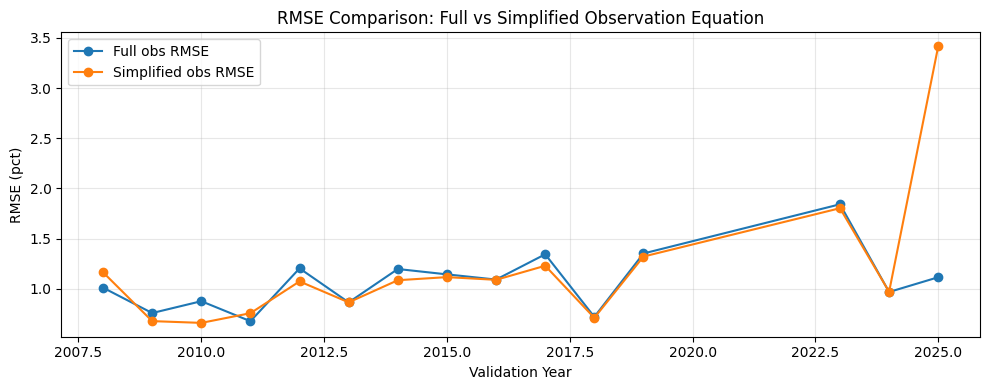

In [15]:
# 4.2 简化观测方程后再拟合：pred = c + k * (I/N)


def fit_one_fold_linear_obs(train_df, valid_df, omega_start):
    fold_df = pd.concat([train_df, valid_df], axis=0).sort_values("week_start").copy()
    start_date = fold_df["week_start"].min()

    t_all = (fold_df["week_start"] - start_date).dt.days.to_numpy(dtype=float)
    h3_all = fold_df["h3n2_pct"].to_numpy(dtype=float)

    t_train = (train_df["week_start"] - start_date).dt.days.to_numpy(dtype=float)
    t_valid = (valid_df["week_start"] - start_date).dt.days.to_numpy(dtype=float)

    y_train = train_df[DP["target_col"]].to_numpy(dtype=float) / ili_scale
    y_valid = valid_df[DP["target_col"]].to_numpy(dtype=float) / ili_scale

    c_fixed = float(np.percentile(y_train, DP["percentile_baseline"]))

    tmp = train_df.copy()
    tmp["week_of_year"] = tmp["week_start"].dt.isocalendar().week.astype(int)
    week_mean = tmp.groupby("week_of_year")[DP["target_col"]].mean()
    week_count = int(RT["seasonal_weeks"])
    week_mean = week_mean.reindex(np.arange(1, week_count + 1), method="nearest")
    season_week = (week_mean / week_mean.mean()).to_numpy(dtype=float)
    season_week = np.clip(season_week, RT["season_week_clip"][0], RT["season_week_clip"][1])

    season_week_x = (np.arange(1, week_count + 1) - 1) * RT["days_per_week"]
    season_week_ext = np.r_[season_week, season_week[0]]
    season_week_x_ext = np.r_[season_week_x, week_count * RT["days_per_week"]]

    def h3_interp(t):
        return np.interp(t, t_all, h3_all)

    def season_interp(t):
        t_mod = np.mod(t, week_count * RT["days_per_week"])
        return np.interp(t_mod, season_week_x_ext, season_week_ext)

    def seir_rhs(t, y, beta0, a, phi, w_h3, w_season, omega):
        s, e, i, r = y
        season_cos = 1.0 + a * np.cos(2 * np.pi * (t / RT["days_per_year"]) - phi)
        season_data = season_interp(t)
        seasonal = season_cos * np.exp(w_season * (season_data - 1.0))
        h3_effect = np.exp(w_h3 * h3_interp(t))
        beta_t = beta0 * seasonal * h3_effect

        ds = -beta_t * s * i / N + omega * r
        de = beta_t * s * i / N - sigma * e
        di = sigma * e - gamma * i
        dr = gamma * i - omega * r
        return [ds, de, di, dr]

    def simulate(theta, t_eval, t_span, y0=None):
        beta0, a, phi, k, w_h3, w_season, omega = theta

        if y0 is None:
            i0 = max(N * max(y_train[0] - c_fixed, 1e-5) / max(k, 1e-6), 1.0)
            e0 = max(E0_mult * i0, 1.0)
            s0 = max(N - i0 - e0, 0.0)
            y0 = [s0, e0, i0, 0.0]

        sol = solve_ivp(
            seir_rhs,
            t_span=t_span,
            y0=y0,
            t_eval=t_eval,
            args=(beta0, a, phi, w_h3, w_season, omega),
            method=RT["ode_method"],
        )
        return sol

    def predict_series(theta, sol):
        _, _, _, k, _, _, _ = theta
        infection_ratio = np.clip(sol.y[2] / N, 0.0, 1.0)
        pred = c_fixed + k * infection_ratio
        return np.clip(pred, 0.0, 1.0)

    def residual(theta):
        sol = simulate(theta, t_eval=t_train, t_span=(0.0, float(t_train.max())))
        if (not sol.success) or sol.y.shape[1] != len(t_train):
            return np.full_like(y_train, 1e6)
        pred = predict_series(theta, sol)
        if not np.isfinite(pred).all():
            return np.full_like(y_train, 1e6)
        return pred - y_train

    theta0 = np.array([
        OPT["beta0"]["initial"],
        OPT["a"]["initial"],
        OPT["phi"]["initial"],
        OPT["k"]["initial"],
        OPT["w_h3"]["initial"],
        OPT["w_season"]["initial"],
        omega_start,
    ], dtype=float)
    lb = np.array([
        OPT["beta0"]["bounds"][0],
        OPT["a"]["bounds"][0],
        OPT["phi"]["bounds"][0],
        OPT["k"]["bounds"][0],
        OPT["w_h3"]["bounds"][0],
        OPT["w_season"]["bounds"][0],
        OPT["omega"]["bounds"][0],
    ], dtype=float)
    ub = np.array([
        OPT["beta0"]["bounds"][1],
        OPT["a"]["bounds"][1],
        OPT["phi"]["bounds"][1],
        OPT["k"]["bounds"][1],
        OPT["w_h3"]["bounds"][1],
        OPT["w_season"]["bounds"][1],
        OPT["omega"]["bounds"][1],
    ], dtype=float)

    fit = least_squares(
        residual,
        x0=theta0,
        bounds=(lb, ub),
        loss=OPT["loss_function"],
        max_nfev=int(RT["optimizer_max_nfev"]),
    )

    sol_train = simulate(fit.x, t_eval=t_train, t_span=(0.0, float(t_train.max())))
    if (not sol_train.success) or sol_train.y.shape[1] == 0:
        raise ValueError("训练段积分失败，无法进行状态传递。")

    final_state = sol_train.y[:, -1]
    t_eval_valid = t_valid
    t_span_valid = (float(t_train.max()), float(t_valid.max()))
    sol_valid = simulate(fit.x, t_eval=t_eval_valid, t_span=t_span_valid, y0=final_state)
    if (not sol_valid.success) or sol_valid.y.shape[1] != len(t_valid):
        raise ValueError("验证段积分失败，请检查时间轴或参数范围。")

    pred_valid = predict_series(fit.x, sol_valid)
    mae = float(np.mean(np.abs(pred_valid - y_valid))) * ili_scale
    rmse = float(np.sqrt(np.mean((pred_valid - y_valid) ** 2))) * ili_scale

    pred_df = valid_df[["week_start", "year", DP["target_col"]]].copy()
    pred_df["pred_ili_pct"] = pred_valid * ili_scale

    return fit.x, mae, rmse, pred_df, c_fixed


metric_rows_simple = []
pred_parts_simple = []

for train_years, valid_year in expanding_folds_no_covid:
    train_fold = df_no_covid[df_no_covid["year"].isin(train_years)].copy()
    valid_fold = df_no_covid[df_no_covid["year"] == valid_year].copy()

    if len(train_fold) < int(CV["min_train_samples"]) or len(valid_fold) < int(CV["min_valid_samples"]):
        continue

    theta, mae, rmse, fold_pred, c_fixed = fit_one_fold_linear_obs(train_fold, valid_fold, omega_init)
    metric_rows_simple.append(
        {
            "train_year_start": min(train_years),
            "train_year_end": max(train_years),
            "valid_year": int(valid_year),
            "n_train": len(train_fold),
            "n_valid": len(valid_fold),
            "MAE_pct": mae,
            "RMSE_pct": rmse,
            "beta0": theta[0],
            "a": theta[1],
            "phi": theta[2],
            "k": theta[3],
            "omega": theta[6],
            "c_fixed_pct": c_fixed * ili_scale,
        }
    )
    pred_parts_simple.append(fold_pred)

cv_metric_df_simple = pd.DataFrame(metric_rows_simple)
cv_pred_df_simple = pd.concat(pred_parts_simple, ignore_index=True) if pred_parts_simple else pd.DataFrame()

if cv_metric_df_simple.empty:
    raise ValueError("简化观测方程后没有可用折，请检查样本量和最小样本阈值。")

simple_compare = pd.DataFrame(
    {
        "Model": ["Full observation", "Simplified observation"],
        "Mean_MAE_pct": [cv_metric_df_no_covid["MAE_pct"].mean(), cv_metric_df_simple["MAE_pct"].mean()],
        "Mean_RMSE_pct": [cv_metric_df_no_covid["RMSE_pct"].mean(), cv_metric_df_simple["RMSE_pct"].mean()],
    }
)
print("=== 简化观测方程再拟合结果 ===")
print(cv_metric_df_simple[["valid_year", "beta0", "a", "phi", "omega", "k", "MAE_pct", "RMSE_pct"]].to_string(index=False))
print("\n=== 与原观测方程对比 ===")
print(simple_compare.to_string(index=False))

# 参数是否仍然贴着初值：简化观测方程版本
simple_drift = build_drift_table(cv_metric_df_simple.rename(columns={"omega": "omega"}), "Simplified observation")
print("\n=== 简化观测方程下参数初值偏移 ===")
print(simple_drift[["model", "param", "init", "mean", "std", "mean_abs_dev", "max_abs_dev", "within_atol_ratio"]].to_string(index=False))

plt.figure(figsize=(10, 4))
plt.plot(cv_metric_df_no_covid["valid_year"], cv_metric_df_no_covid["RMSE_pct"], marker="o", label="Full obs RMSE")
plt.plot(cv_metric_df_simple["valid_year"], cv_metric_df_simple["RMSE_pct"], marker="o", label="Simplified obs RMSE")
plt.title("RMSE Comparison: Full vs Simplified Observation Equation")
plt.xlabel("Validation Year")
plt.ylabel("RMSE (pct)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()